# Exploration de données : Projet Sell4All

Ce notebook a pour but d'analyser et de nettoyer les données des clients de l'entreprise Sell4All. L'objectif final est de préparer ces données pour un futur modèle d'intelligence artificielle.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

## 1. Lecture des données
Nous commençons par lire le fichier CSV contenant les informations des utilisateurs.

In [2]:
df = pd.read_csv('dataset-sell4all.csv')
df.head()

,Name,Phone Number,Email,Address,Country,Postal code,Last date of connection,Last time of connection,Age,Gender,Customer spendings
0,Aaron Cote,966-7625,elit@hotmail.org,699-5837 Risus Street,Norway,4126,5-Apr-21,4:39,71,Man,356
1,Angelica Lawson,232-3051,diam.proin@google.org,481-8428 Magna. Street,Pakistan,518885,"oct. 10, 2021",0:36,37,Women,173
2,Louis Gilbert,1-997-733-0134,lorem.fringilla@hotmail.org,Ap #192-2082 Enim. Ave,Colombia,575444,2-Jul-22,3:37,24,Women,105
3,Basia Finley,1-987-322-7148,tristique.aliquet@icloud.co,608-2732 Nec Rd.,South Africa,5973-5765,19-Feb-22,2:34,37,Women,28
4,Rhona Sears,387-7682,iaculis.odio.nam@protonmail.org,8763 In Rd.,France,37476,31-Mar-22,6:28,42,Women,13


## 2. Résumé technique des données
Nous affichons un résumé technique de notre jeu de données pour comprendre sa structure.

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Name                     505 non-null    object
 1   Phone Number             505 non-null    object
 2   Email                    505 non-null    object
 3   Address                  505 non-null    object
 4   Country                  505 non-null    object
 5   Postal code              505 non-null    object
 6   Last date of connection  505 non-null    object
 7   Last time of connection  505 non-null    object
 8   Age                      505 non-null    int64 
 9   Gender                   505 non-null    object
 10  Customer spendings       505 non-null    int64 
dtypes: int64(2), object(9)
memory usage: 43.5+ KB


### Explication du résumé technique :

- **Combien y a-t-il d’entrées dans l’ensemble de données ?** 
  L'ensemble de données contient 505 entrées (lignes) numérotées de l'index 0 à 504.

- **Qu’est-ce que « non nul » ?** 
  Le terme « non nul » (ou non-null) indique le nombre de valeurs qui existent réellement et qui ne sont pas vides dans une colonne. Par exemple, si une colonne possède 505 valeurs non nulles, cela signifie qu'il n'y a aucune donnée manquante pour cette variable.

- **Quels types de données sont présents dans l’ensemble de données ?**
  Les types de données présents sont principalement :
  - `int64` : représente les nombres entiers (utilisé par exemple pour l'âge et les dépenses des clients).
  - `object` : représente du texte ou des chaînes de caractères (utilisé par exemple pour le nom, le pays, le genre, etc.).

## 3. Analyse statistique basique
Calcul de la moyenne et de la médiane pour les colonnes Age et Customer spendings.

In [4]:
# Calcul de la moyenne et de la médiane pour l'Age
mean_age = df['Age'].mean()
median_age = df['Age'].median()

# Calcul de la moyenne et de la médiane pour les dépenses (Customer spendings)
mean_spendings = df['Customer spendings'].mean()
median_spendings = df['Customer spendings'].median()

print(f"Moyenne d'âge : {mean_age:.2f} ans")
print(f"Médiane d'âge : {median_age} ans")
print(f"Moyenne des dépenses : {mean_spendings:.2f} €")
print(f"Médiane des dépenses : {median_spendings} €")

Moyenne d'âge : 46.08 ans
Médiane d'âge : 46.0 ans
Moyenne des dépenses : 311.17 €
Médiane des dépenses : 307.0 €


### Bonus : Calcul de la médiane d'âge pour chaque pays

In [5]:
median_age_by_country = df.groupby('Country')['Age'].median()
print(median_age_by_country)

Country
Australia             44.0
Austria               43.0
Belgium               39.0
Brazil                49.5
Canada                46.0
Chile                 46.0
China                 35.0
Colombia              29.0
Costa Rica            48.0
France                56.5
Germany               53.0
India                 45.5
Indonesia             41.5
Ireland               49.0
Italy                 41.0
Mexico                47.0
Netherlands           48.0
New Zealand           38.0
Nigeria               37.0
Norway                54.0
Pakistan              44.0
Peru                  38.0
Philippines           51.0
Poland                49.5
Russian Federation    48.0
Singapore             41.5
South Africa          43.0
South Korea           49.5
Spain                 54.5
Sweden                40.0
Turkey                60.0
Ukraine               46.0
United Kingdom        48.5
United States         48.5
Vietnam               48.0
Name: Age, dtype: float64


## 4. Visualisation des données
Graphique à barres illustrant les dépenses totales par pays.

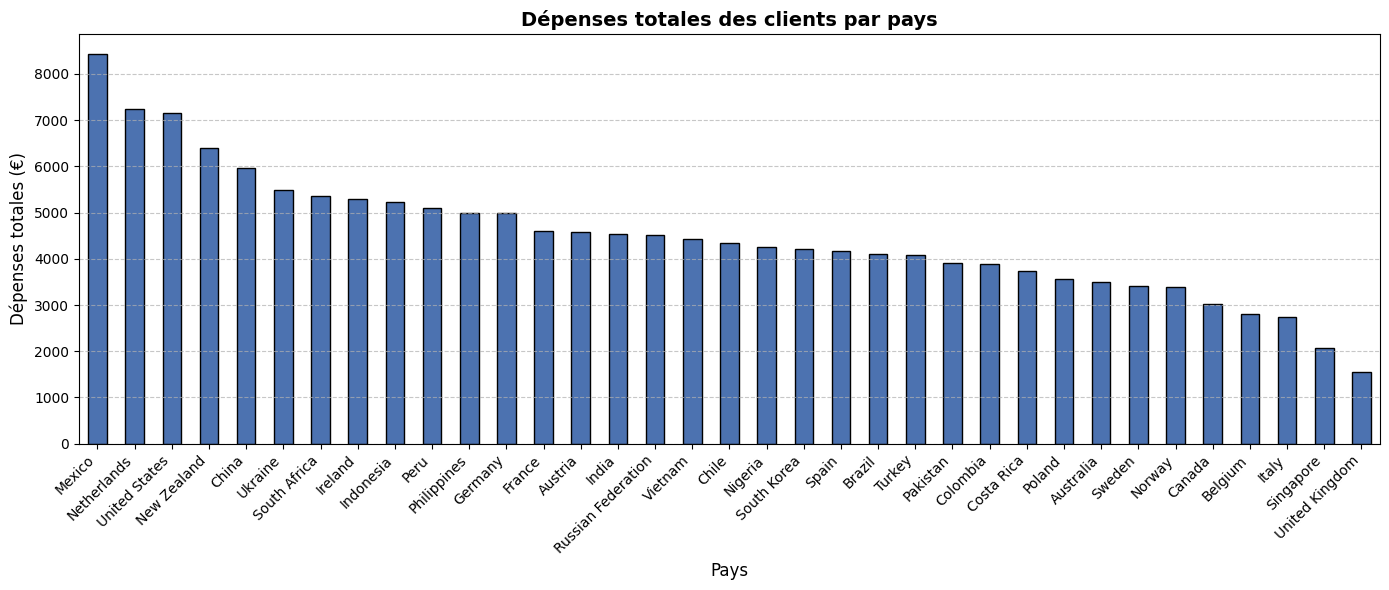

In [6]:
# Regrouper les dépenses par pays et faire la somme, puis trier par ordre décroissant
spendings_by_country = df.groupby('Country')['Customer spendings'].sum().sort_values(ascending=False)

# Création du graphique
plt.figure(figsize=(14, 6))
spendings_by_country.plot(kind='bar', color='#4C72B0', edgecolor='black')

plt.title('Dépenses totales des clients par pays', fontsize=14, fontweight='bold')
plt.xlabel('Pays', fontsize=12)
plt.ylabel('Dépenses totales (€)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## 5. Nettoyage des données
Préparation du dataset pour le modèle en supprimant les doublons et les utilisateurs ayant dépensé moins de 10 €.

In [7]:
# Suppression des lignes avec moins de 10 € de dépenses
df_cleaned = df[df['Customer spendings'] >= 10]

# Suppression des lignes dupliquées
df_cleaned = df_cleaned.drop_duplicates()

# Conservation uniquement des colonnes requises : Country, Age, Gender, Customer spendings
columns_to_keep = ['Country', 'Age', 'Gender', 'Customer spendings']
df_cleaned = df_cleaned[columns_to_keep]

# Affichage d'un aperçu des données nettoyées
df_cleaned.head()

,Country,Age,Gender,Customer spendings
0,Norway,71,Man,356
1,Pakistan,37,Women,173
2,Colombia,24,Women,105
3,South Africa,37,Women,28
4,France,42,Women,13


## 6. Exportation du fichier nettoyé
Sauvegarde des données propres dans un nouveau fichier CSV.

In [8]:
df_cleaned.to_csv('cleaned_dataset-sell4all.csv', index=False)
print("Les données nettoyées ont été sauvegardées avec succès.")

Les données nettoyées ont été sauvegardées avec succès.
